# Init

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import skimage
from sklearn import datasets, linear_model, metrics, model_selection, neighbors, preprocessing, svm as sksvm

In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
np.set_printoptions(threshold=20, edgeitems=10, linewidth=140, precision=3, suppress=True)

# MNIST digits dataset

In [3]:
X_all, y_all = datasets.fetch_openml('mnist_784', data_home='../data/mnist_784', return_X_y=True, as_frame=False)
print(X_all.shape, X_all.dtype, X_all.min(), X_all.max())
print(y_all.shape, y_all.dtype, y_all.min(), y_all.max())

c:\Users\Karel\miniconda3\envs\ima23\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(70000, 784) float64 0.0 255.0
(70000,) object 0 9


In [4]:
y_all = y_all.astype(int)
y_all.shape, y_all.dtype, y_all.min(), y_all.max()

((70000,), dtype('int32'), 0, 9)

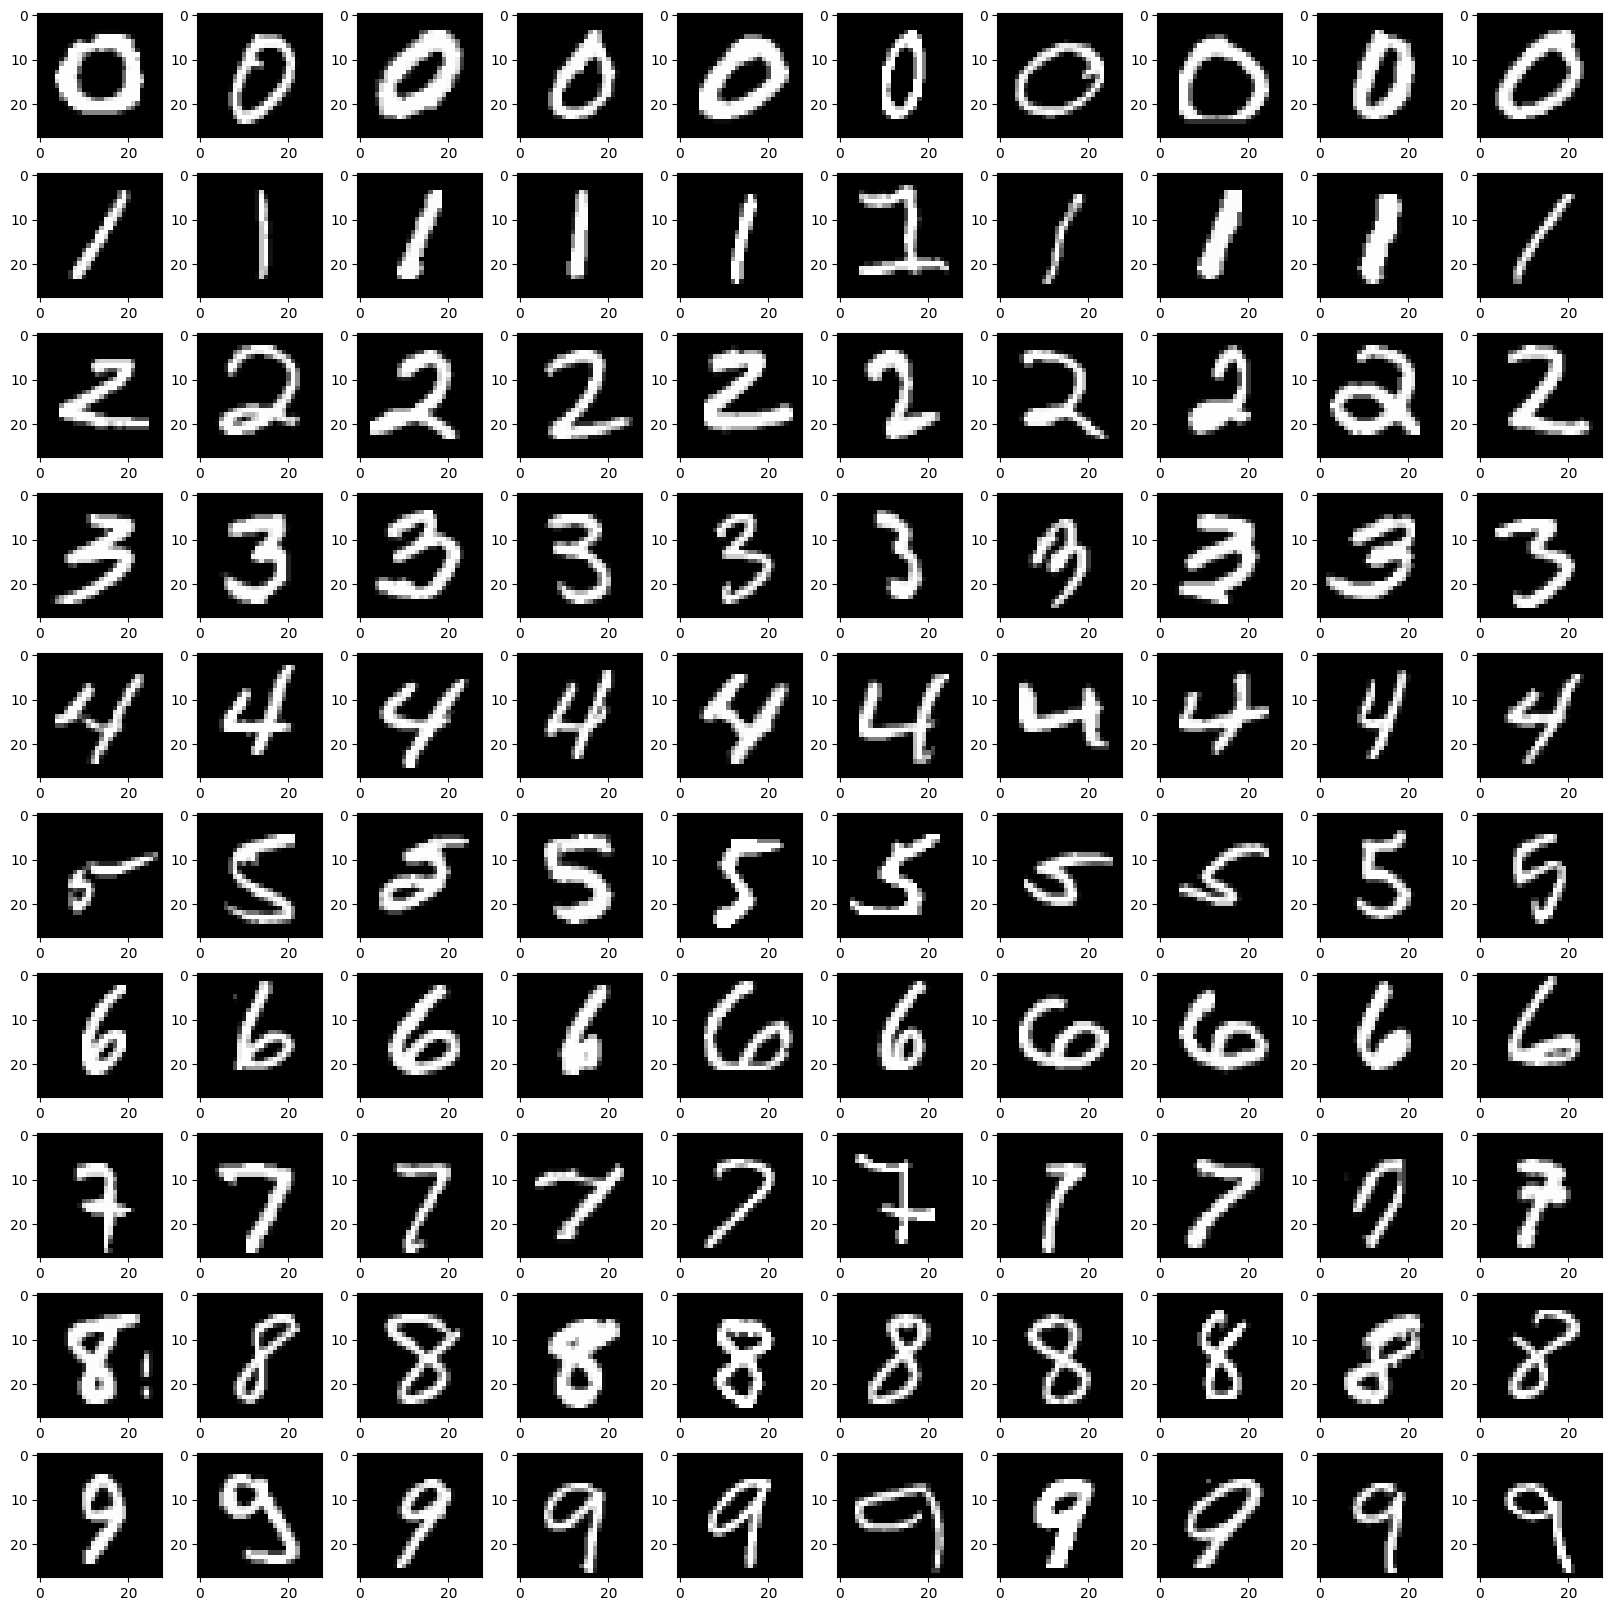

In [5]:
fig, axes = plt.subplots(10, 10, figsize=(16, 16))
for n in range(10):
    ids, = np.where(y_all == n)
    ids = np.random.choice(ids, size=10)
    for i, j in enumerate(ids):
        axes[n, i].imshow(X_all[j].reshape(28, 28), cmap='gray', vmin=0.0, vmax=255.0)

## Split into training and validation

In [6]:
X_train, X_val, y_train, y_val = model_selection.train_test_split(X_all, y_all, test_size=10000, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((60000, 784), (10000, 784), (60000,), (10000,))

# Nearest neighbor classifier in `sklearn`

In [7]:
knn = neighbors.KNeighborsClassifier(n_neighbors=10, algorithm='brute')
knn

KNeighborsClassifier(algorithm='brute', n_neighbors=10)

In [8]:
%%time

knn.fit(X_train, y_train)

CPU times: total: 78.1 ms
Wall time: 80.6 ms


KNeighborsClassifier(algorithm='brute', n_neighbors=10)

In [9]:
%%time

y_train_knn = knn.predict(X_train)

CPU times: total: 2min 28s
Wall time: 19.1 s


In [10]:
%%time

y_val_knn = knn.predict(X_val)

CPU times: total: 26.2 s
Wall time: 3.39 s


In [11]:
# calculate accuracy
print('KNN train accuracy', np.mean(y_train_knn == y_train))
print('KNN validaiton accuracy', np.mean(y_val_knn == y_val))

KNN train accuracy 0.9749666666666666
KNN validaiton accuracy 0.9655


# Support vector machine

In [12]:
svm = sksvm.LinearSVC(multi_class='ovr')
svm

LinearSVC()

In [13]:
%%time

svm.fit(X_train, y_train)

c:\Users\Karel\miniconda3\envs\ima23\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


CPU times: total: 2min 5s
Wall time: 2min 5s


c:\Users\Karel\miniconda3\envs\ima23\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC()

In [14]:
%%time

y_train_svm = svm.predict(X_train)

CPU times: total: 688 ms
Wall time: 119 ms


In [15]:
%%time

y_val_svm = svm.predict(X_val)

CPU times: total: 15.6 ms
Wall time: 24 ms


In [16]:
# calculate accuracy
print('SVM train accuracy', np.mean(y_train_svm == y_train))
print('SVM validaiton accuracy', np.mean(y_val_svm == y_val))

SVM train accuracy 0.7887833333333333
SVM validaiton accuracy 0.778


## Improving SVM by preprocessing

In [17]:
X_train_prep = X_train / 255 - 0.5
X_val_prep = X_val / 255 - 0.5

In [18]:
# # Alternatively, try this instead
# prep = preprocessing.StandardScaler()
# prep.fit(X_train, y_train)
# X_train_prep = prep.transform(X_train)
# X_val_prep = prep.transform(X_val)

In [19]:
svm_prep = sksvm.LinearSVC(multi_class='ovr')
svm_prep.fit(X_train_prep, y_train)

c:\Users\Karel\miniconda3\envs\ima23\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Karel\miniconda3\envs\ima23\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC()

In [20]:
y_train_svm_prep = svm_prep.predict(X_train_prep)
y_val_svm_prep = svm_prep.predict(X_val_prep)

In [21]:
# calculate accuracy
print('SVM prep train accuracy', np.mean(y_train_svm_prep == y_train))
print('SVM prep validaiton accuracy', np.mean(y_val_svm_prep == y_val))

SVM prep train accuracy 0.9270166666666667
SVM prep validaiton accuracy 0.9146


## Improving SVM by using nonlinear kernel

In [22]:
%%time

svc_rbf = sksvm.SVC(kernel=metrics.pairwise.rbf_kernel, decision_function_shape='ovr')
svc_rbf.fit(X_train_prep, y_train)

CPU times: total: 3min 28s
Wall time: 1min 17s


SVC(kernel=<function rbf_kernel at 0x000001F7048298A0>)

In [23]:
%%time

y_train_svc_rbf = svc_rbf.predict(X_train_prep)
y_val_svc_rbf = svc_rbf.predict(X_val_prep)

CPU times: total: 4min 28s
Wall time: 1min 30s


In [24]:
# calculate accuracy
print('SVM RBF prep train accuracy', np.mean(y_train_svc_rbf == y_train))
print('SVM RBF prep validaiton accuracy', np.mean(y_val_svc_rbf == y_val))

SVM RBF prep train accuracy 0.94375
SVM RBF prep validaiton accuracy 0.9402
